### 1. Import Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from google.colab import drive
import warnings
warnings.filterwarnings('ignore')


drive.mount('/content/drive/')

Mounted at /content/drive/


In [2]:
dfNYC = pd.read_csv('/content/drive/MyDrive/tubes vdi/NYC.csv')
dfTKY = pd.read_csv('/content/drive/MyDrive/tubes vdi/TKY.csv')

In [3]:
dfNYC.head()

,userId,venueId,venueCategoryId,venueCategory,latitude,longitude,timezoneOffset,utcTimestamp
0,470,49bbd6c0f964a520f4531fe3,4bf58dd8d48988d127951735,Arts & Crafts Store,40.719810,-74.002581,-240,Tue Apr 03 18:00:09 +0000 2012
1,979,4a43c0aef964a520c6a61fe3,4bf58dd8d48988d1df941735,Bridge,40.606800,-74.044170,-240,Tue Apr 03 18:00:25 +0000 2012
2,69,4c5cc7b485a1e21e00d35711,4bf58dd8d48988d103941735,Home (private),40.716162,-73.883070,-240,Tue Apr 03 18:02:24 +0000 2012
3,395,4bc7086715a7ef3bef9878da,4bf58dd8d48988d104941735,Medical Center,40.745164,-73.982519,-240,Tue Apr 03 18:02:41 +0000 2012
4,87,4cf2c5321d18a143951b5cec,4bf58dd8d48988d1cb941735,Food Truck,40.740104,-73.989658,-240,Tue Apr 03 18:03:00 +0000 2012


In [4]:
dfTKY.head()

,userId,venueId,venueCategoryId,venueCategory,latitude,longitude,timezoneOffset,utcTimestamp
0,1541,4f0fd5a8e4b03856eeb6c8cb,4bf58dd8d48988d10c951735,Cosmetics Shop,35.705101,139.619590,540,Tue Apr 03 18:17:18 +0000 2012
1,868,4b7b884ff964a5207d662fe3,4bf58dd8d48988d1d1941735,Ramen / Noodle House,35.715581,139.800317,540,Tue Apr 03 18:22:04 +0000 2012
2,114,4c16fdda96040f477cc473a5,4d954b0ea243a5684a65b473,Convenience Store,35.714542,139.480065,540,Tue Apr 03 19:12:07 +0000 2012
3,868,4c178638c2dfc928651ea869,4bf58dd8d48988d118951735,Food & Drink Shop,35.725592,139.776633,540,Tue Apr 03 19:12:13 +0000 2012
4,1458,4f568309e4b071452e447afe,4f2a210c4b9023bd5841ed28,Housing Development,35.656083,139.734046,540,Tue Apr 03 19:18:23 +0000 2012


### 2. Preprocessing Data

In [5]:
print(dfNYC.info())
print(dfTKY.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227428 entries, 0 to 227427
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   userId           227428 non-null  int64  
 1   venueId          227428 non-null  object 
 2   venueCategoryId  227428 non-null  object 
 3   venueCategory    227428 non-null  object 
 4   latitude         227428 non-null  float64
 5   longitude        227428 non-null  float64
 6   timezoneOffset   227428 non-null  int64  
 7   utcTimestamp     227428 non-null  object 
dtypes: float64(2), int64(2), object(4)
memory usage: 13.9+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 573703 entries, 0 to 573702
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   userId           573703 non-null  int64  
 1   venueId          573703 non-null  object 
 2   venueCategoryId  573703 non-null  object 
 3   ve

In [6]:
print(dfTKY.isnull().sum())
print(dfNYC.isnull().sum())

userId             0
venueId            0
venueCategoryId    0
venueCategory      0
latitude           0
longitude          0
timezoneOffset     0
utcTimestamp       0
dtype: int64
userId             0
venueId            0
venueCategoryId    0
venueCategory      0
latitude           0
longitude          0
timezoneOffset     0
utcTimestamp       0
dtype: int64


In [7]:
dfNYC.drop(columns=['venueId', 'venueCategoryId', 'timezoneOffset'], inplace=True)
dfTKY.drop(columns=['venueId', 'venueCategoryId', 'timezoneOffset'], inplace=True)

In [8]:
# 3. Konversi format waktu
dfTKY['utcTimestamp'] = pd.to_datetime(dfTKY['utcTimestamp'], errors='coerce', format='%a %b %d %H:%M:%S %z %Y')
dfNYC['utcTimestamp'] = pd.to_datetime(dfNYC['utcTimestamp'], errors='coerce', format='%a %b %d %H:%M:%S %z %Y')


### 3. Normalisasi Data

In [9]:
# 1. Normalisasi nama kolom (jika diperlukan)
dfTKY.columns = [col.lower() for col in dfTKY.columns]
dfNYC.columns = [col.lower() for col in dfNYC.columns]

# 2. Menstandarkan tipe data
dfTKY['userid'] = dfTKY['userid'].astype('int64')
dfNYC['userid'] = dfNYC['userid'].astype('int64')

# 3. Normalisasi teks di kolom venueCategory
dfTKY['venuecategory'] = dfTKY['venuecategory'].str.strip().str.title()
dfNYC['venuecategory'] = dfNYC['venuecategory'].str.strip().str.title()


In [10]:
# Cek jumlah nilai null untuk setiap kolom
null_counts_tky = dfTKY.isnull().sum()
null_counts_nyc = dfNYC.isnull().sum()

# Cek jumlah baris duplikat
duplicate_count_tky = dfTKY.duplicated().sum()
duplicate_count_nyc = dfNYC.duplicated().sum()

# Menampilkan hasil
print("Nilai null di dataset Tokyo:")
print(null_counts_tky[null_counts_tky > 0])

print("\nJumlah data duplikat di dataset Tokyo:")
print(duplicate_count_tky)

print("\nNilai null di dataset NYC:")
print(null_counts_nyc[null_counts_nyc > 0])

print("\nJumlah data duplikat di dataset NYC:")
print(duplicate_count_nyc)


Nilai null di dataset Tokyo:
Series([], dtype: int64)

Jumlah data duplikat di dataset Tokyo:
577

Nilai null di dataset NYC:
Series([], dtype: int64)

Jumlah data duplikat di dataset NYC:
262


### 4. Visualisasi Data

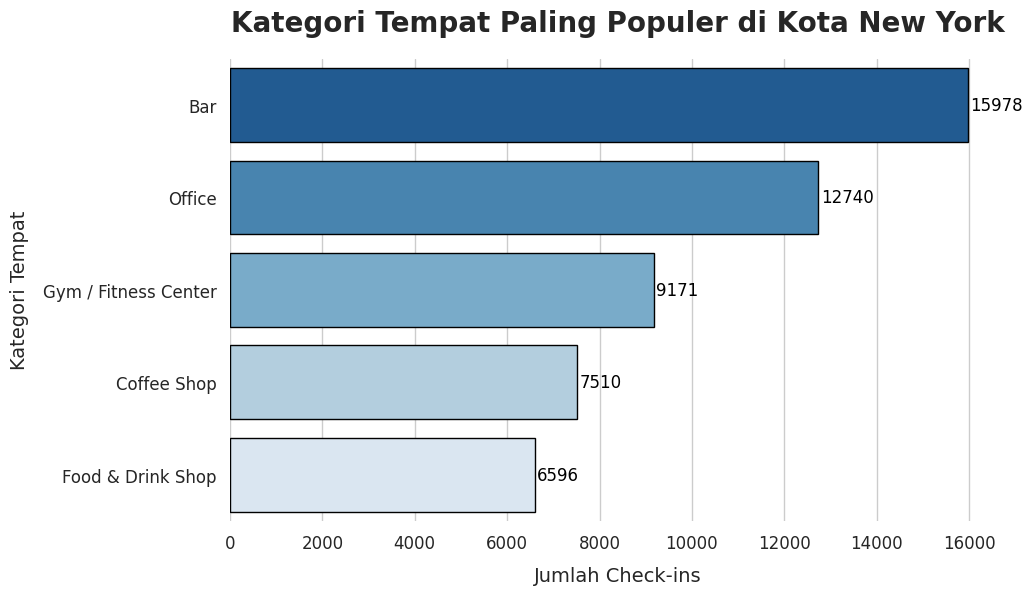

In [11]:
filtered_data = dfNYC[(dfNYC['venuecategory'] != 'Home (Private)') & (dfNYC['venuecategory'] != 'Subway')]
filtered_category_counts = filtered_data['venuecategory'].value_counts().head(5)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.barplot(
    x=filtered_category_counts.values,
    y=filtered_category_counts.index,
    palette="Blues_r",
    edgecolor="black"
)
sns.despine(left=True, bottom=True)

plt.title('Kategori Tempat Paling Populer di Kota New York', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Jumlah Check-ins', fontsize=14, labelpad=10)
plt.ylabel('Kategori Tempat', fontsize=14, labelpad=10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

for index, value in enumerate(filtered_category_counts.values):
    plt.text(value + 50, index, str(value), fontsize=12, va='center', color='black')

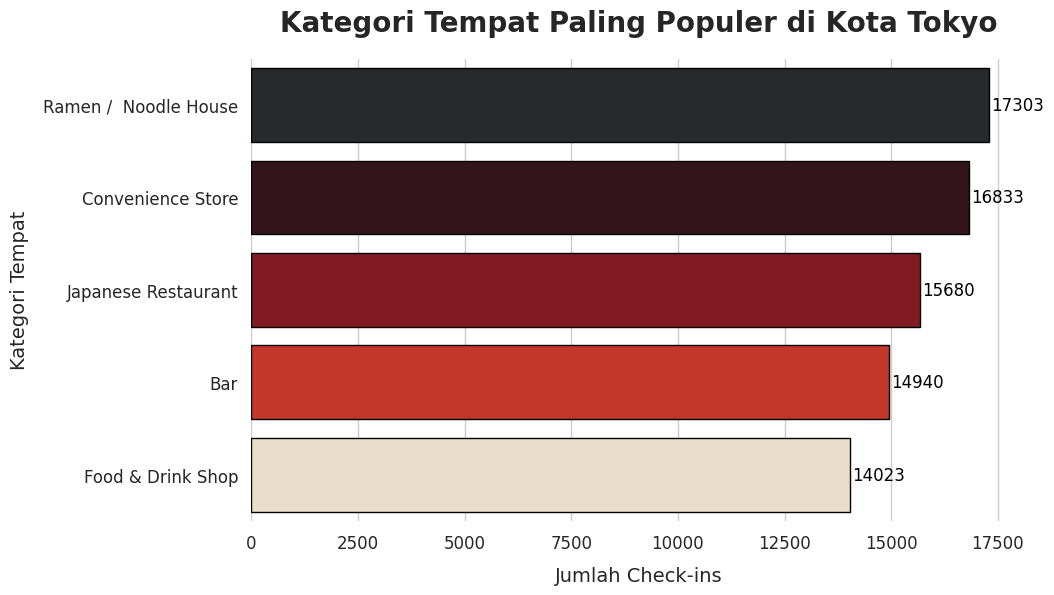

In [12]:
filtered_data = dfTKY[(dfTKY['venuecategory'] != 'Train Station') & (dfTKY['venuecategory'] != 'Subway')]
filtered_category_counts = filtered_data['venuecategory'].value_counts().head(5)

japanese_palette = ['#252B2B', '#380F17', '#8F0B13', '#DC2011', '#EFDFC5']

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.barplot(
    x=filtered_category_counts.values,
    y=filtered_category_counts.index,
    palette=japanese_palette,
    edgecolor="black"
)
sns.despine(left=True, bottom=True)

plt.title('Kategori Tempat Paling Populer di Kota Tokyo', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Jumlah Check-ins', fontsize=14, labelpad=10)
plt.ylabel('Kategori Tempat', fontsize=14, labelpad=10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

for index, value in enumerate(filtered_category_counts.values):
    plt.text(value + 50, index, str(value), fontsize=12, va='center', color='black')

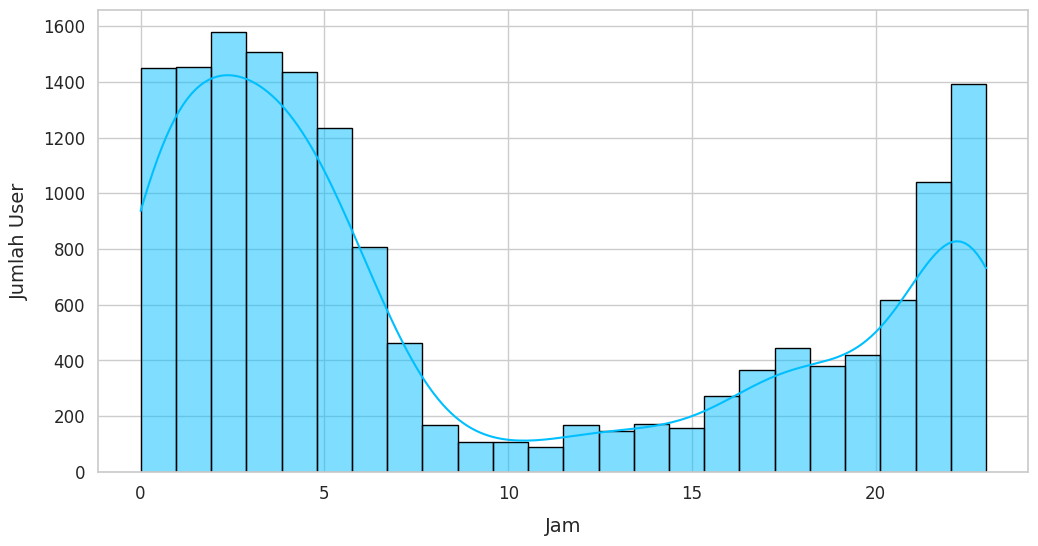

In [19]:

bar_data = dfNYC[dfNYC['venuecategory'] == 'Bar']
bar_data['utctimestamp'] = pd.to_datetime(bar_data['utctimestamp'])
bar_data['hour'] = bar_data['utctimestamp'].dt.hour

plt.figure(figsize=(12, 6))
sns.histplot(bar_data['hour'], bins=24, kde=True, color="#00BFFF", edgecolor="black")
plt.xlabel('Jam', fontsize=14, labelpad=10)
plt.ylabel('Jumlah User', fontsize=14, labelpad=10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()


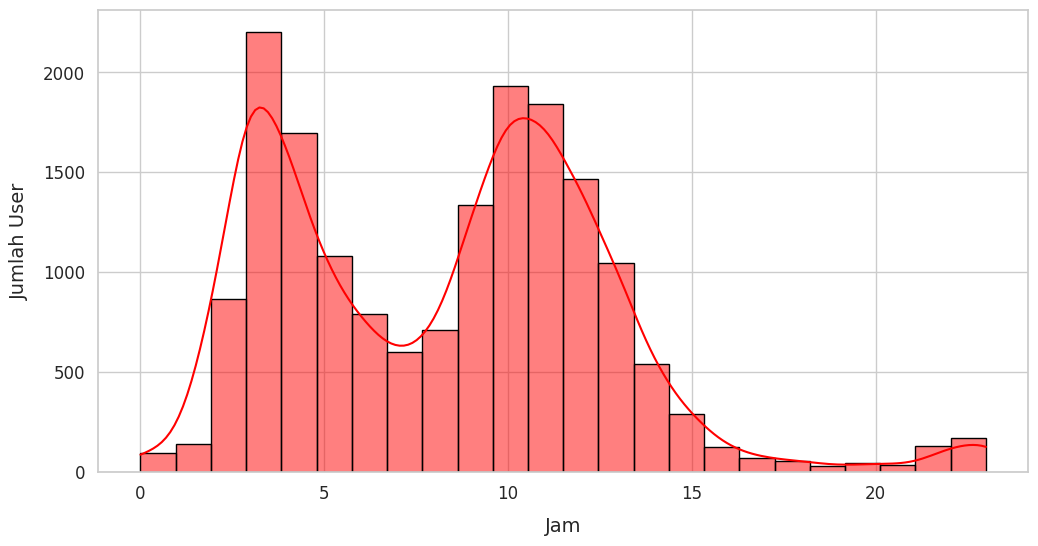

In [20]:

noodle_data = dfTKY[dfTKY['venuecategory'] == 'Ramen /  Noodle House']
noodle_data['utctimestamp'] = pd.to_datetime(noodle_data['utctimestamp'])
noodle_data['hour'] = noodle_data['utctimestamp'].dt.hour

plt.figure(figsize=(12, 6))
sns.histplot(noodle_data['hour'], bins=24, kde=True, color="#FF0000", edgecolor="black")

plt.xlabel('Jam', fontsize=14, labelpad=10)
plt.ylabel('Jumlah User', fontsize=14, labelpad=10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [25]:
import folium
from folium.plugins import MarkerCluster

# Pastikan dataset memiliki kolom latitude dan longitude
# Jika dataset memiliki nama yang berbeda untuk kolom lat dan lon, sesuaikan nama kolomnya.
dfNYC['latitude'] = dfNYC['latitude']
dfNYC['longitude'] = dfNYC['longitude']

# Kelompokkan data berdasarkan lokasi dan hitung jumlah aktivitas di setiap lokasi
location_activity = dfNYC.groupby(['latitude', 'longitude']).size().reset_index(name='activity_count')

# Temukan lokasi dengan aktivitas tertinggi
top_location = location_activity.sort_values(by='activity_count', ascending=False).head(10)

# Buat peta interaktif
m = folium.Map(location=[top_location['latitude'].mean(), top_location['longitude'].mean()], zoom_start=12)

# Tambahkan marker cluster untuk menandai lokasi-lokasi
marker_cluster = MarkerCluster().add_to(m)

# Tambahkan marker untuk setiap lokasi dengan aktivitas terbanyak
for _, row in top_location.iterrows():
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=f"Lokasi: ({row['latitude']}, {row['longitude']})<br>Aktivitas: {row['activity_count']}",
        icon=folium.Icon(color='blue', icon='info-sign')
    ).add_to(marker_cluster)

# Simpan dan tampilkan peta interaktif
m.save('location_activity_map.html')
m


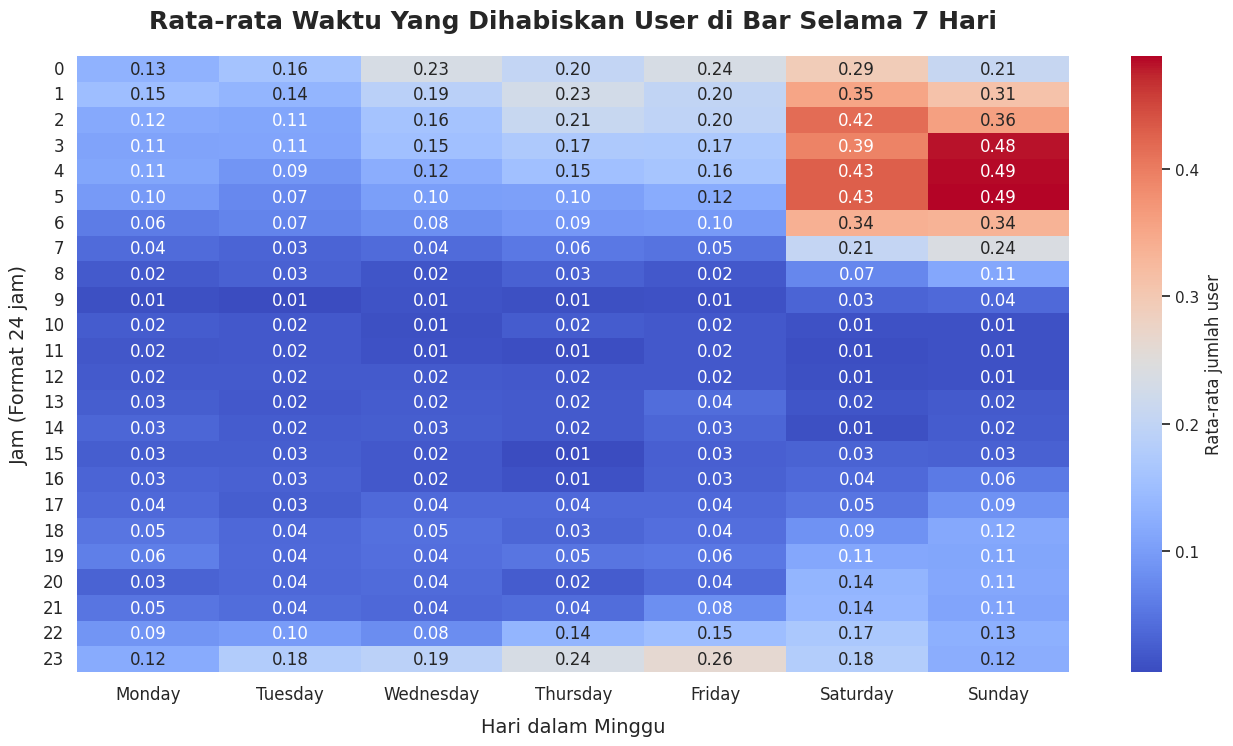

In [26]:
# Bar

bar_data = dfNYC[dfNYC['venuecategory'] == 'Bar']

if bar_data.empty:
    print("Data untuk kategori 'Bar' di New York kosong.")
else:
    bar_data['utctimestamp'] = pd.to_datetime(bar_data['utctimestamp'])
    bar_data['day_of_week'] = bar_data['utctimestamp'].dt.day_name()  # Nama hari dalam minggu
    bar_data['roundedTime'] = bar_data['utctimestamp'].apply(
        lambda x: x.replace(minute=0) + pd.Timedelta(hours=1) if x.minute >= 30 else x.replace(minute=0)
    )
    bar_data['hour'] = bar_data['roundedTime'].dt.hour

    # Grup data berdasarkan hari dalam minggu dan jam
    grouped_data = bar_data.groupby(['day_of_week', 'hour']).size().reset_index(name='checkins')
    grouped_data['avg_users'] = grouped_data['checkins'] / bar_data['userid'].nunique()

    # Pivot data
    pivot_data = grouped_data.pivot(index='hour', columns='day_of_week', values='avg_users')
    pivot_data = pivot_data.reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], axis=1)  # Urutan hari
    pivot_data = pivot_data.fillna(0)  # Isi nilai NaN dengan 0

    # Visualisasi heatmap
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(16, 8))
    sns.heatmap(
        pivot_data, cmap="coolwarm", annot=True, fmt=".2f",
        cbar_kws={'label': 'Rata-rata jumlah user'}
    )

    plt.title('Rata-rata Waktu Yang Dihabiskan User di Bar Selama 7 Hari', fontsize=18, fontweight='bold', pad=20)
    plt.xlabel('Hari dalam Minggu', fontsize=14, labelpad=10)
    plt.ylabel('Jam (Format 24 jam)', fontsize=14, labelpad=10)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12, rotation=0)
    plt.show()

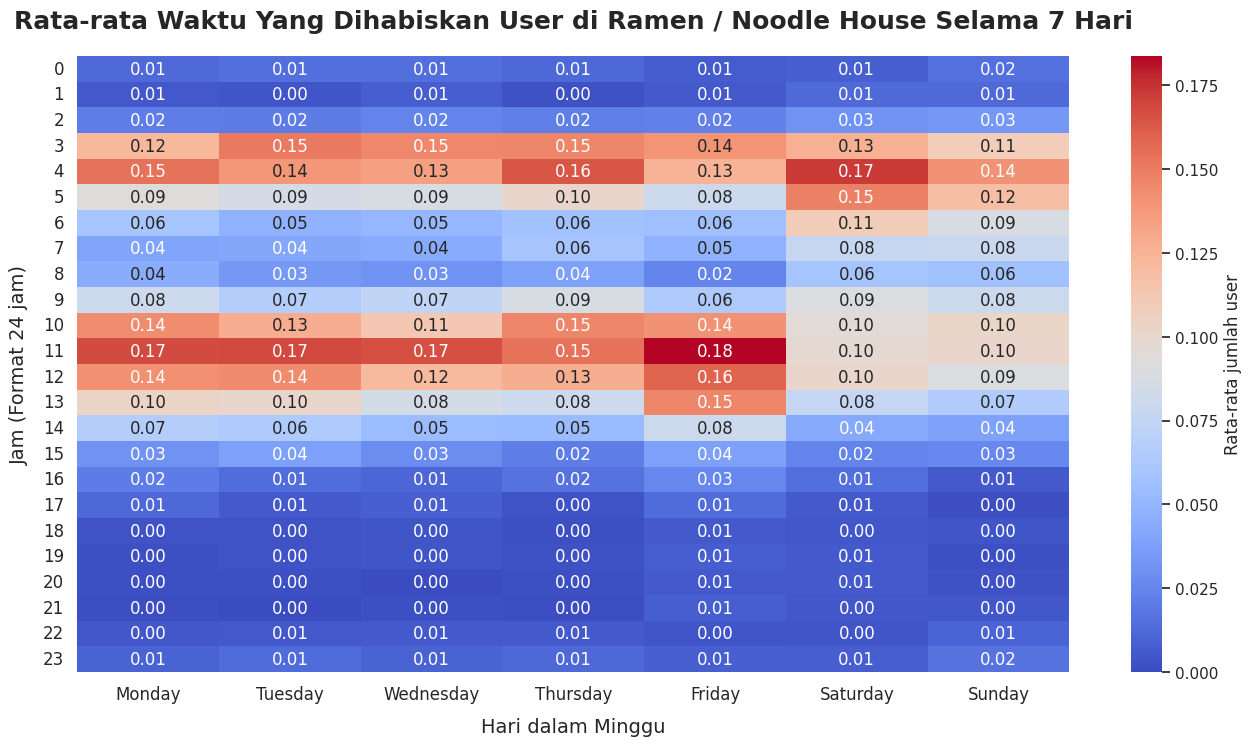

In [27]:
# Ramen /  Noodle House

noodle_data = dfTKY[dfTKY['venuecategory'] == 'Ramen /  Noodle House']

if noodle_data.empty:
    print("Data untuk kategori 'Ramen / Noodle House' di Tokyo kosong.")
else:
    noodle_data['utctimestamp'] = pd.to_datetime(noodle_data['utctimestamp'])
    noodle_data['day_of_week'] = noodle_data['utctimestamp'].dt.day_name()
    noodle_data['roundedTime'] = noodle_data['utctimestamp'].apply(
        lambda x: x.replace(minute=0) + pd.Timedelta(hours=1) if x.minute >= 30 else x.replace(minute=0)
    )
    noodle_data['hour'] = noodle_data['roundedTime'].dt.hour

    # Grup data berdasarkan hari dalam minggu dan jam
    grouped_noodle_data = noodle_data.groupby(['day_of_week', 'hour']).size().reset_index(name='checkins')
    grouped_noodle_data['avg_users'] = grouped_noodle_data['checkins'] / noodle_data['userid'].nunique()

    # Pivot data
    pivot_noodle_data = grouped_noodle_data.pivot(index='hour', columns='day_of_week', values='avg_users')
    pivot_noodle_data = pivot_noodle_data.reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], axis=1)
    pivot_noodle_data = pivot_noodle_data.fillna(0)  # Isi nilai NaN dengan 0

    # Visualisasi heatmap
    plt.figure(figsize=(16, 8))
    sns.heatmap(
        pivot_noodle_data, cmap="coolwarm", annot=True, fmt=".2f",
        cbar_kws={'label': 'Rata-rata jumlah user'}
    )

    plt.title('Rata-rata Waktu Yang Dihabiskan User di Ramen / Noodle House Selama 7 Hari', fontsize=18, fontweight='bold', pad=20)
    plt.xlabel('Hari dalam Minggu', fontsize=14, labelpad=10)
    plt.ylabel('Jam (Format 24 jam)', fontsize=14, labelpad=10)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12, rotation=0)
    plt.show()